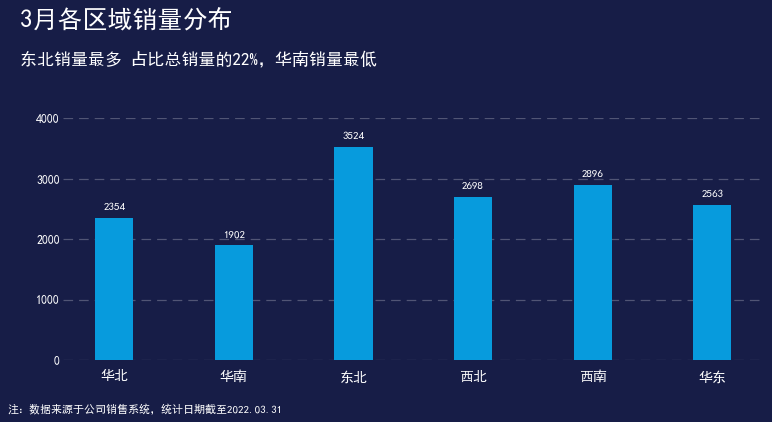

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1. 设置中文字体
# =========================
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

# =========================
# 2. 数据
# =========================
data = {
    '区域': ['华北', '华南', '东北', '西北', '西南', '华东'],
    '销售量': [2354, 1902, 3524, 2698, 2896, 2563]
}

df = pd.DataFrame(data)

# 如果你的数据在 Excel 中，可以把上面改成：
# df = pd.read_excel('销售数据.xlsx')

# =========================
# 3. 自动计算分析结论
# =========================
total = df['销售量'].sum()

max_row = df.loc[df['销售量'].idxmax()]
min_row = df.loc[df['销售量'].idxmin()]

max_region = max_row['区域']
max_sales = max_row['销售量']

min_region = min_row['区域']

percentage = max_sales / total * 100

subtitle = (
    f'{max_region}销量最多 占比总销量的{percentage:.0f}%，'
    f'{min_region}销量最低'
)

# =========================
# 4. 创建图表
# =========================
fig, ax = plt.subplots(figsize=(12, 7))

# 深蓝色背景
background_color = '#171d47'

fig.patch.set_facecolor(background_color)
ax.set_facecolor(background_color)

# 柱状图
bars = ax.bar(
    df['区域'],
    df['销售量'],
    width=0.32,
    color='#079bdd'
)

# =========================
# 5. Y轴设置
# =========================
ax.set_ylim(0, 4000)

ax.set_yticks([0, 1000, 2000, 3000, 4000])

ax.tick_params(
    axis='y',
    colors='white',
    labelsize=12,
    length=0
)

ax.tick_params(
    axis='x',
    colors='white',
    labelsize=14,
    length=0,
    pad=10
)

# =========================
# 6. 横向虚线网格
# =========================
ax.grid(
    axis='y',
    linestyle=(0, (8, 5)),
    linewidth=1.2,
    alpha=0.25,
    color='white'
)

ax.set_axisbelow(True)

# 去掉边框
for spine in ax.spines.values():
    spine.set_visible(False)

# =========================
# 7. 给柱子加数据标签
# =========================
for bar, value in zip(bars, df['销售量']):
    
    ax.text(
        bar.get_x() + bar.get_width()/2,
        value + 120,
        f'{value}',
        ha='center',
        va='bottom',
        fontsize=11,
        color='white'
    )

# =========================
# 8. 调整绘图区位置
# =========================
plt.subplots_adjust(
    left=0.13,
    right=0.94,
    bottom=0.20,
    top=0.68
)

# =========================
# 9. 主标题
# =========================
fig.text(
    0.08,
    0.86,
    '3月各区域销量分布',
    fontsize=25,
    fontweight='bold',
    color='white'
)

# =========================
# 10. 副标题
# =========================
fig.text(
    0.08,
    0.785,
    subtitle,
    fontsize=17,
    color='white'
)

# =========================
# 11. 底部数据来源
# =========================
fig.text(
    0.065,
    0.095,
    '注：数据来源于公司销售系统，统计日期截至2022.03.31',
    fontsize=11,
    color='white'
)

plt.show()